<a href="https://colab.research.google.com/github/ddblanco/ddblanco.github.io/blob/main/dS3_share.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import mpmath as mp  # librería de alta precisión, sirve cuando los float64 no alcanzan en estabilidad (por ej., series y funciones especiales con argumentos grandes/pequeños o complejos).
import math  #módulo estándar math. Útil para constantes y operaciones en escalares (no arrays, para eso numpy).
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter  # formateador de ticks que muestra números en formato plano (evita notación científica en ejes).

mp.mp.dps = 60  # mp.e**(...), mp.gamma, etc., se calculan con 60 dígitos de precisión. Esto reduce errores de redondeo y mejora estabilidad de series (Wright/Fox–Wright) y en funciones hiperbólicas con argumentos complejos grandes (a costa de tiempo de cómputo, ovbio).

Definiciones comunes

In [2]:
# Heaviside
def H(x):
    return mp.mpf('1.0') if x > 0 else mp.mpf('0.0')

# Volumen clásico: V_cl = 2 π^2 ℓ^3 = 2 π^2 / Λ^(3/2)
def V_cl(Lmb):
    return 2*math.pi**2 / (Lmb**1.5)

# Valor de log(2) numérico
LOG2 = np.log(2.0)

# log(sinh z) numéricamente estable
def logsinh_stable(z):
    """
    Calcula log(sinhz) sin desbordar cuando |Re(z)| es muy grande.
    Si Re(z) >> 1: lo escribo así log(sinh(z)) = z − log(2) + log(1 − e^{−2z}) (análogo para Re(z)<<1).
    Eso evita calcular e^z grande (cuando al final después sólo te interesa tomarle el log).
    """
    z = np.asarray(z, dtype=np.complex128)
    a = z.real
    out = np.empty_like(z, dtype=np.complex128)
    big = 20.0
    m_pos = a > big
    m_neg = a < -big
    m_mid = ~(m_pos | m_neg)
    out[m_pos] = z[m_pos] + np.log(1.0 - np.exp(-2.0*z[m_pos])) - LOG2
    out[m_neg] = -z[m_neg] + np.log(1.0 - np.exp( 2.0*z[m_neg])) - LOG2
    out[m_mid] = np.log(np.sinh(z[m_mid]))
    return out

# Función de Wright W_{1/2,0}(z)
def wright_W_half_0(z, Kmax=300):
    # Fórmula general: W_{λ,μ}(z) = sum_{k=0}^\infty z^k / (k! Γ(λ k + μ)). Tomamos λ=1/2, μ=0. Sumo k>=1.
    s = mp.mpf('0')
    for k in range(1, Kmax+1):
        den = mp.factorial(k) * mp.gamma(mp.mpf('0.5')*k)  # denominador
        term = (z**k) / den  # término de la suma
        s += term
        if abs(term) < mp.eps*1e3:  # Cortar la suma cuando los términos ya no contribuyen tanto
            break
    return s

# Función de Fox–Wright 1Ψ2((1,1); (5,1), (1/2,1/2); z) por serie truncada
# Parámetros:  (a1,A1) = (1,1),  (b1,B1) = (5,1), (b2,B2) = (1/2, 1/2).
# 1Ψ2 = sum_{k=0}^∞ Γ(1+1*k) / [ Γ(5+1*k) Γ(1/2 + (1/2)k) ] * z^k / k!
def fox_wright_1psi2(z, Kmax=300):
    s = mp.mpf('0')
    for k in range(Kmax+1):
        num = mp.gamma(1 + k)   # numerador
        den = mp.gamma(5 + k) * mp.gamma(mp.mpf('0.5') + mp.mpf('0.5')*k)   # denominador
        term = (num/den) * (z**k) / mp.factorial(k)  # término de la suma
        s += term
        if abs(term) < mp.eps*1e3:   # Cortar la suma cuando los términos ya no contribuyen tanto
            break
    return s

def pV_from_logZ(Vs, Lmb, GN, Vmax, logZ_func, N=4096, oversamp=1.25, sigma_frac=0.45):
    """
    Dado logZ_func(Λ,GN) que devuelve log Z(Λ) para cada caso, calcula p(V) con el mismo procedimiento para todos los casos.
    Argumentos (los no obvios):
    Vs: malla de volúmenes para los cuales calculamos p(V)
    Vmax: escala en V a cubrir; determina dt y con N la ventana de integración [-T,T]
    logZ_func: la implementación de logZ para cada caso (all_loop, exact)
    N: puntos en t
    oversamp: factor que disminuye dt para evitar aliasing en V
    sigma_frac: entra en el suavizado con gaussiana del borde de la ventana de integración para atenuar efectos de sinc (en esta versión no se usa, lo dejo por si más adelante queremos meter el suavizado de vuelta)
    """
    # malla de t y ventana
    dt = np.pi/(oversamp*Vmax)
    T  = dt * N/2.0
    t  = np.linspace(-T, T-dt, N)
    tau = 20
    w   = np.exp(-(t/tau)**2)

    # φ(t) = Z(Λ - i t 8π G_N) / Z(Λ)
    logZ_den = logZ_func(Lmb + 0j, GN)
    logZ_num = logZ_func(Lmb - 1j*t*8*np.pi*GN, GN)
    phi = np.exp(logZ_num - logZ_den)

    g = phi * w

    # p(V) ≈ (1/2π) ∫ e^{-i t V} g(t) dt
    p = []
    for V in Vs:
        val = (dt/(2*np.pi)) * np.sum(g * np.exp(-1j * t * V))
        p.append(val.real)
    return np.array(p)

Saddle

In [3]:
# Saddle dS^3 (ignorando la δ(V))
# p(V) = H(V)/V * exp[-Λ V/(8π G_N) - C3/(G_N √Λ)] * W_{1/2,0}( z ), con C3 = π/2 y z = [8π C3 V^{1/2}] / (8π G_N)^{3/2}
def pV_saddle(V, Lmb, GN, Kmax=300):   # si el argumento es grande y la serie tarda en converger se puede subir el Kmax o aumentar arriba el mp.mp.dps
    if V <= 0:
        return mp.mpf('0')
    C3 = mp.pi/2
    expo = mp.e**( - Lmb*V/(8*mp.pi*GN) - C3/(GN*mp.sqrt(Lmb)) )
    z = (8*mp.pi*C3*mp.sqrt(V)) / ( (8*mp.pi*GN)**(mp.mpf('3')/2) )
    return H(V) * expo * wright_W_half_0(z, Kmax=Kmax) / V

One loop

In [4]:
mp.mp.dps = 300  # precisión decimal
eps = 1e-11
# Wright W_{1/2,1/2}(z)
def wright(z, Kmax=300):
    s = mp.mpf('0')
    for k in range(0, Kmax+1):
        den = mp.factorial(k) * mp.gamma(k/2+1/2)
        term = (z**k) / den
        s += term
        if abs(term) < mp.eps*1e3:
            break
    return s

#Heaviside suave
def theta_eps(V, eps):
    if V<=0:
        return 0
    return mp.e**(-eps/V)

"""
#Heaviside suave con tanh
def theta_eps(V, eps):
    return 0.5 * (1 + mp.tanh(V / eps))
"""

# Parte dentro del operador (1 + a d/dV)^2, para V>0
def f_reg(V, G, Lam):

    z = mp.sqrt(mp.pi * V) / mp.sqrt(32 * G**3)

    return (
        mp.sqrt(Lam / (8 * mp.pi * G * V)) * theta_eps(V,eps)
        * mp.e**(-mp.pi / (2 * G * mp.sqrt(Lam)) - Lam * V / (8 * mp.pi * G))
        * wright(z)
    )

# p(V)


def pV(V, G, Lam):

    a = 8 * mp.pi * G / Lam
    f = lambda u: f_reg(u, G, Lam)

    val = f(V) + 2*a*mp.diff(f, V) + a**2 * mp.diff(f, V, 2)
    return float(val)

def pV_one_loop(V, Lmb, GN):
    return pV(V,GN,Lmb)

All loop


In [5]:
def logZ_all_loop(Lmb_complex, GN):
    """
    log Z para:
        Z = exp(2π k) * [2 / sqrt(4 + k^2)] * sin(π/(2 + i k)) * sin(π/(2 - i k)),
    con k = 1/(4 G_N sqrt(Λ)).
    """
    Lc = np.asarray(Lmb_complex, dtype=np.complex128)
    k  = 1.0 / (4.0 * GN * np.sqrt(Lc))

    # Términos
    log_pref  = 2.0*np.pi*k
    log_sqrt  = np.log(2.0) - 0.5*np.log(4.0 + k*k)
    log_sin_p = np.log(np.sin(np.pi / (2.0 + 1j*k)))
    log_sin_m = np.log(np.sin(np.pi / (2.0 - 1j*k)))

    logZ = log_pref + log_sqrt + log_sin_p + log_sin_m
    return logZ

def pV_all_loop(Vs, Lmb, GN, Vmax, N=4096, oversamp=1.25, sigma_frac=0.45):
    """
    p(V) all loop
    """
    Vs = np.asarray(Vs, dtype=float)
    return pV_from_logZ(
        Vs=Vs,
        Lmb=Lmb,
        GN=GN,
        Vmax=Vmax,
        logZ_func=logZ_all_loop,
        N=N,
        oversamp=oversamp,
        sigma_frac=sigma_frac
    )

No perturbativa


In [ ]:
def logZ_grav_exact(Lmb_complex, GN):
    """
    log Z_grav(S^3) con b^2 = i / (4 G_N sqrt(Λ)).
    """
    Lc = np.asarray(Lmb_complex, dtype=np.complex128)
    y = 1.0 / (4.0 * GN * np.sqrt(Lc))  # = κ
    # Z = -16 i y / (1 + y^2)^2 * sinh(π y)^2 * sinh(π / y)^2
    logZ = (np.log(-16j * y)
            - 2.0 * np.log(1.0 + y*y)
            + 2.0 * logsinh_stable(np.pi * y)
            + 2.0 * logsinh_stable(np.pi / y))
    return logZ

def pV_exact(Vs, Lmb, GN, Vmax, N=4096, oversamp=1.25, sigma_frac=0.45):
    """
    p(V) exacta (caso gravitacional) a partir de logZ_grav_exact.

    Argumentos (los no obvios):
    Vs : array_like
        Puntos de volumen V donde se evalúa p(V).
       Vmax : float
        Corte de volumen que fija el paso temporal dt = π / (oversamp * Vmax).
    N : int, opcional
        Número de puntos de la malla temporal (por defecto 4096).
    oversamp : float, opcional
        Factor de sobre-muestreo en t (por defecto 1.25).
    sigma_frac : float, opcional
        Fracción para el ancho de la ventana gaussiana (en esta versión no se usa, lo dejo por si más adelante queremos meter el suavizado de vuelta)

    Devuelve
    --------
    np.ndarray
        Array real con p(V) evaluada en Vs.
    """
    Vs = np.asarray(Vs, dtype=float)
    return pV_from_logZ(
        Vs=Vs,
        Lmb=Lmb,
        GN=GN,
        Vmax=Vmax,
        logZ_func=logZ_grav_exact,
        N=N,
        oversamp=oversamp,
        sigma_frac=sigma_frac
    )

Gráficos

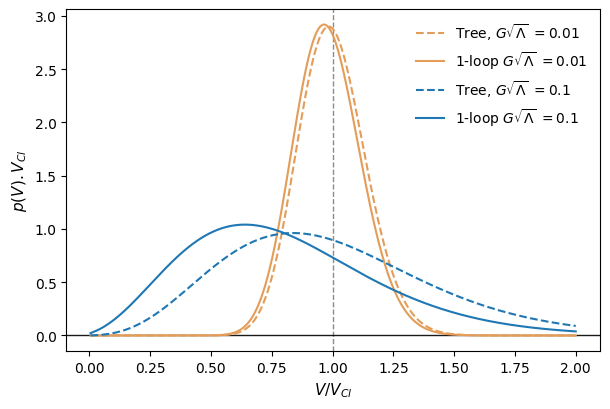

In [6]:
# ==================== Gráficos ====================
# Λ y volumen clásico
# Λ = (0.03)**2
Λ = 1
Vcl  = V_cl(Λ)
Vmax = 2 * Vcl
eps = 1e-4

# malla de V
Vs = np.linspace(1e-1, Vmax, 700)  # si hay mucho alrededor de V=0 empezar desde 1e-3

# Tres valores de G_N = s / sqrt(Λ)
s_values = [0.01,0.1]
colors   = ['#E39D59', '#1F77B4']
sqrtΛ    = math.sqrt(Λ)
GN_values = [s / sqrtΛ for s in s_values]

# Control de precisión
KMAX       = 500
NFFT       = 4096
oversamp   = 50     # Subir para suprimir osc numéricas en la no perturbativa
sigma_frac = 0.45   # en esta versión no se usa

# ==================== Auxiliares/vectorización ====================
def eval_scalar_fun(fun, Vs, Λ, GN, **kw):
    """Evalúa funciones del tipo f(v,Λ,GN,...) para toda la malla Vs."""
    yy = np.array([fun(v, Λ, GN, **kw) for v in Vs], dtype=float)
    return yy

def eval_array_fun(fun, Vs, Λ, GN, **kw):
    """Evalúa funciones vectorizadas tipo f(Vs,Λ,GN,...) -> array."""
    yy = np.asarray(fun(Vs, Λ, GN, **kw)).real
    return yy

# ==================== Gráfico ====================
plt.figure(figsize=(6.2, 4.2))

"""
Descomentar dentro del siguiente for para graficar cada función
"""

for GN, s, c in zip(GN_values, s_values, colors):

    # Tree
    ps = eval_scalar_fun(pV_saddle, Vs, Λ, GN, Kmax=KMAX)
    plt.plot(Vs/Vcl, ps*Vcl, color=c, lw=1.5, ls='--',
             label=rf"Tree, $G\sqrt{{\Lambda}}$ $={GN:.3g}$")

    # All-loop
    #pall = eval_array_fun(pV_all_loop, Vs, Λ, GN,
    #                      Vmax=Vmax, N=NFFT, oversamp=oversamp, sigma_frac=sigma_frac)
    #plt.plot(Vs, pall, color=c, lw=1.5, ls="-",
    #         label=fr"all-loop $G\sqrt{{\Lambda}}$ $={GN:.3g}$")

    # Exact
    #pex = eval_array_fun(pV_exact, Vs, Λ, GN,
    #                     Vmax=Vmax, N=NFFT, oversamp=oversamp, sigma_frac=sigma_frac)
    #plt.plot(Vs, pex, color=c, lw=1.5, ls='-',
    #label=fr"exact $G\sqrt{{\Lambda}}$ $={GN:.3g}$")

    # 1-loop
    p1 = eval_scalar_fun(pV_one_loop, Vs, Λ, GN)
    plt.plot(Vs/Vcl, p1*Vcl, color=c, lw=1.5, ls='-',
             label=fr"1-loop $G\sqrt{{\Lambda}}$ $={GN:.3g}$")

# Línea vertical en V_cl
plt.axvline(1, color='grey', linestyle="--", linewidth=1, alpha=0.9, zorder=0.5)


plt.axhline(0, color='black', linestyle="-", linewidth=1, alpha=0.9, zorder=0.5)

# Ejes, ticks, leyenda
plt.xlabel(r"$V/V_{Cl}$", fontsize=11)
plt.ylabel(r"$p(V).V_{Cl}$", fontsize=11)
plt.legend(frameon=False, fontsize=10, ncol=1)

ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style='plain', axis='both')
ax.get_xaxis().get_offset_text().set_visible(False)
ax.get_yaxis().get_offset_text().set_visible(False)

plt.tight_layout()
plt.show()

Valor de expectación y varianza (hubo algún overflow en alguna corrida por un sinh, revisar por las dudas)

/tmp/ipython-input-3807049492.py:12: RuntimeWarning: overflow encountered in sinh
  V2 = -(2*np.pi**4 / Lmb**3) / np.sinh(np.pi/(4*G*r))**2


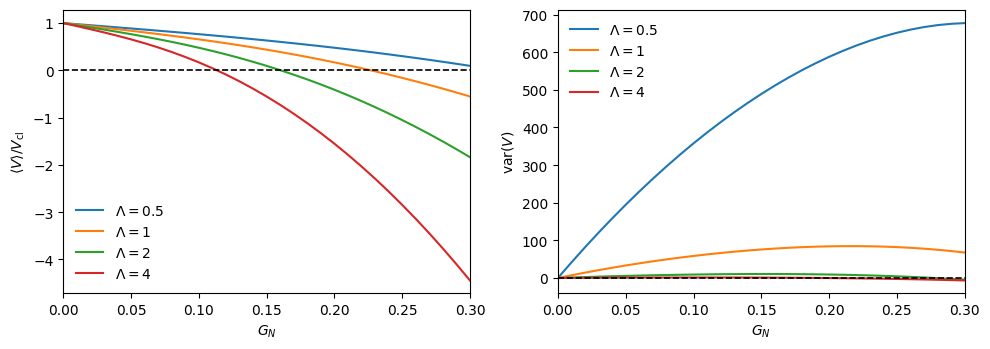

In [ ]:
# --- fórmulas ec. (44) ---
def meanV_np(Lmb, G):
    r = np.sqrt(Lmb)
    T1 = (2*np.pi**2 / Lmb**1.5) / np.tanh(np.pi/(4*G*r))
    T2 = -(32*np.pi**2 * G**2 / r) / np.tanh(4*np.pi*G*r)
    T3 = (4*np.pi*G / Lmb) * ((16*G**2*Lmb - 3) / (16*G**2*Lmb + 1))
    return T1 + T2 + T3

def varV_np(Lmb, G):
    r = np.sqrt(Lmb)
    V1 = (24*np.pi**3*G / Lmb**2.5) / np.tanh(np.pi/(4*G*r))
    V2 = -(2*np.pi**4 / Lmb**3) / np.sinh(np.pi/(4*G*r))**2
    V3 = -(128*np.pi**3*G**3 / Lmb**1.5) / np.tanh(4*np.pi*G*r)
    V4 = -(512*np.pi**4*G**4 / Lmb) / np.sinh(4*np.pi*G*r)**2
    V5 = (32*np.pi**2*G**2 / Lmb**2) * ((16*G**2*Lmb - 3) / (16*G**2*Lmb + 1))
    V6 = -(2048*np.pi**2*G**4 / Lmb) / (16*G**2*Lmb + 1)**2
    return V1 + V2 + V3 + V4 + V5 + V6

# --- parámetros del plot ---
Gs_left  = [0.0001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1,
 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2,
 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3]        # panel izq.
Ls_left  = [0.5, 1.0, 2.0, 4.0]

Gs_right = [0.0001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1,
 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2,
 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3]        # panel der.
Ls_right = [0.5, 1.0, 2.0, 4.0]
# --- figura ---
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 3.6))

# izquierda: <V>/Vcl vs G
for L in Ls_left:
    y = [meanV_np(L, G)/V_cl(L) for G in Gs_left]
    axL.plot(Gs_left, y, marker='', label=rf'$\Lambda={L:g}$')
axL.axhline(0.0, ls='--', c='k', lw=1.2)
axL.set_xlabel(r'$G$')
axL.set_ylabel(r'$\langle V\rangle/V_{\rm cl}$')
axL.set_xlim(0, 0.30)
axL.legend(frameon=False)

# derecha: Var(V) vs G
for L in Ls_right:
    y = [varV_np(L, G) for G in Gs_right]
    axR.plot(Gs_right, y, marker='', label=rf'$\Lambda={L:g}$')
axR.axhline(0.0, ls='--', c='k', lw=1.2)
axR.set_xlabel(r'$G$')
axR.set_ylabel(r'$\mathrm{var}(V)$')
axR.set_xlim(0, 0.30)
axR.legend(frameon=False)

plt.tight_layout()
plt.show()

Gifs y figuras en paneles (dejo sólo un par de ejemplos por si más adelante queremos hacer otros)

In [ ]:
# === Imágenes: all-loop (sólida) + 1-loop (punteada) ===
import os, math, numpy as np, matplotlib.pyplot as plt, shutil
from matplotlib.ticker import ScalarFormatter
from IPython.display import FileLink, display

def _vec_p1(Vs, Lmb, GN, Kmax=500):
    return np.array([float(pV_one_loop(v, Lmb, GN, Kmax=Kmax)) for v in Vs], dtype=float)

def save_images_all_vs_one(
    Lmb=1.0,
    G_list=(0.10, 0.20, 0.25, 0.30, 0.35),
    Vs_pts=600,
    NFFT=4096, oversamp=1.25, sigma_frac=0.45,
    KMAX_1L=500,
    ylim_percentile=99.5,
    outdir="frames_all_vs_one"
):
    # Malla en V y constantes
    Vcl  = V_cl(Lmb)
    Vmax = 2.0 * Vcl
    Vs   = np.linspace(0.0, Vmax, Vs_pts)
    eps = 1e-4

    # Cálculo previo de curvas para fijar ejes globales razonables
    all_curves, one_curves = [], []
    for G in G_list:
        pall = np.asarray(pV_all_loop(Vs, Lmb, G, Vmax=Vmax, N=NFFT,
                                      oversamp=oversamp, sigma_frac=sigma_frac), dtype=float)
        pone = _vec_p1(Vs, Lmb, G, Kmax=KMAX_1L)
        all_curves.append(pall); one_curves.append(pone)

    all_curves = np.array(all_curves)  # (nG, Vs_pts)
    one_curves = np.array(one_curves)

    both = np.concatenate([all_curves.reshape(-1), one_curves.reshape(-1)])
    ymin = float(min(0.0, np.nanmin(both)))
    ymax = float(np.nanpercentile(both, ylim_percentile))
    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0

    # Dir de salida
    os.makedirs(outdir, exist_ok=True)
    saved = []

    # Generación de cada imagen
    for G, pall, pone in zip(G_list, all_curves, one_curves):
        fig, ax = plt.subplots(figsize=(6.4, 3.6), dpi=120)

        ax.plot(Vs, pall, lw=2.0, color="#1f77b4", label="all-loop")
        ax.plot(Vs, pone, lw=1.8, ls="--", color="#d62728", label="1-loop")
        ax.axhline(0, color='k', ls='--', lw=0.8)
        ax.axvline(Vcl, color='k', ls='--', lw=0.8, label=r"$V_{\rm cl}$")

        # Texto (arriba-izquierda) con Lambda y G; leyenda abajo-derecha
        ax.text(0.02, 0.98, rf"$\Lambda={Lmb:g}$" + "\n" + rf"$G={G:.3f}$",
                transform=ax.transAxes, ha="left", va="top", fontsize=10)
        ax.legend(frameon=False, fontsize=9, loc="lower right")

        ax.set_xlim(0.0, Vmax)
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel(r"$V$", fontsize=11)
        ax.set_ylabel(r"$p(V)$", fontsize=11)

        ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        ax.ticklabel_format(style='plain', axis='both')
        ax.get_xaxis().get_offset_text().set_visible(False)
        ax.get_yaxis().get_offset_text().set_visible(False)

        fig.tight_layout()
        fname = os.path.join(outdir, f"p_all_vs_one_G_{G:.3f}.png")
        fig.savefig(fname)
        plt.close(fig)
        saved.append(fname)

    # Links y ZIP
    for pth in saved:
        print("Guardado:", os.path.abspath(pth))
        display(FileLink(pth))
    zip_path = shutil.make_archive("p_all_vs_one_frames", "zip", outdir)
    print("ZIP con todas:", os.path.abspath(zip_path))
    display(FileLink(zip_path))

# Ejecutar:
save_images_all_vs_one(
    Lmb=1.0,
    G_list=(0.05, 0.15, 0.18, 0.21, 0.4),
    Vs_pts=600,
    NFFT=4096, oversamp=1.25, sigma_frac=0.45,
    KMAX_1L=500,
    ylim_percentile=99.5,
    outdir="frames_all_vs_one"
)

TypeError: pV_one_loop() got an unexpected keyword argument 'Kmax'

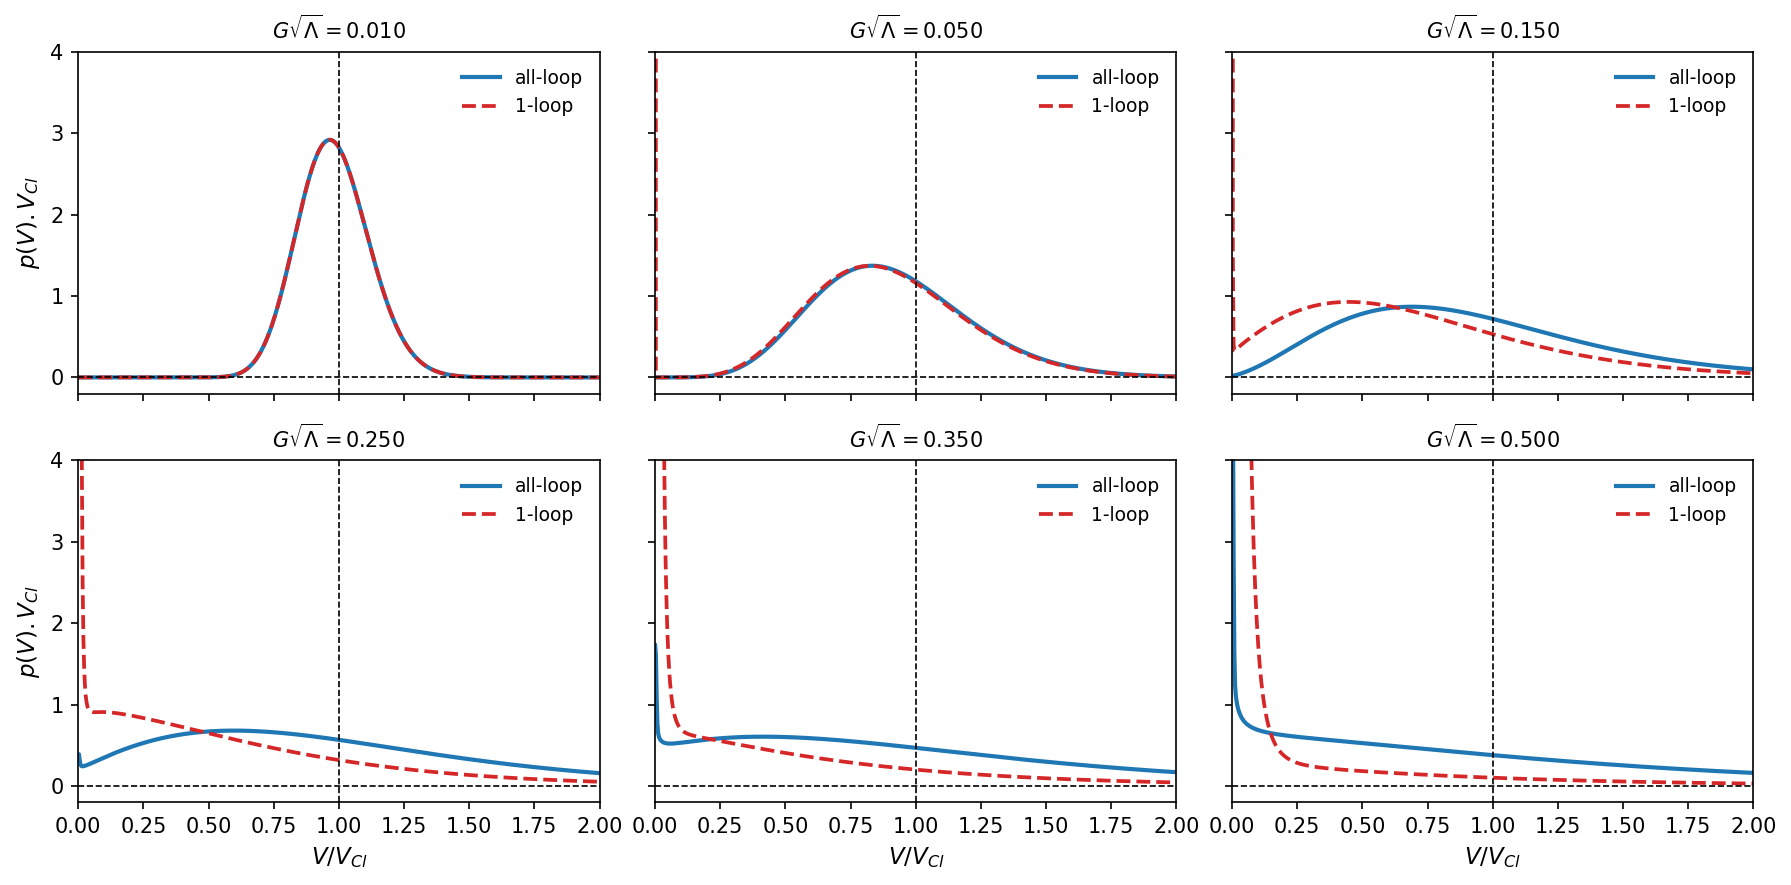

Guardado en: /content/panel_all_vs_one.png


/content/panel_all_vs_one.png

In [ ]:
import os, math, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from IPython.display import FileLink, display

def _vec_p1(Vs, Lmb, GN, Kmax=500):
    return np.array([float(pV_one_loop(v, Lmb, GN)) for v in Vs], dtype=float)

def panel_all_vs_one(
    Lmb=1.0,
    G_list=(0.01, 0.10, 0.15, 0.25, 0.35, 0.5),
    Vs_pts=700,
    NFFT=4096, oversamp=1.25, sigma_frac=0.45,
    KMAX_1L=500,
    ylim_percentile=99.5,
    out_path="panel_all_vs_one.png",
    dpi=150
):
    Vcl  = V_cl(Lmb)
    Vmax = 2.0 * Vcl
    Vs   = np.linspace(1e-8, Vmax, Vs_pts)

    # ---- Precomputar todas las curvas para fijar un único rango vertical ----
    curves = []
    all_vals = []

    for G in G_list:
        pall = np.asarray(
            pV_all_loop(Vs, Lmb, G, Vmax=Vmax,
                        N=NFFT, oversamp=oversamp, sigma_frac=sigma_frac),
            dtype=float
        )
        pone = _vec_p1(Vs, Lmb, G, Kmax=KMAX_1L)

        # mismas magnitudes que graficás: p(V)*Vcl
        pall_plot = pall * Vcl
        pone_plot = pone * Vcl

        curves.append((G, pall_plot, pone_plot))
        all_vals.append(pall_plot)
        all_vals.append(pone_plot)

    all_vals = np.concatenate(all_vals)

    # rango vertical global para TODO el panel
    global_ymin = float(min(0.0, np.nanmin(all_vals)))
    global_ymax = float(np.nanpercentile(all_vals, ylim_percentile))
    if not np.isfinite(global_ymax) or global_ymax <= global_ymin:
        global_ymax = global_ymin + 1.0

    # opcional: pequeño margen visual
    dy = global_ymax - global_ymin
    global_ymin -= 0.03 * dy
    global_ymax += 0.03 * dy

    fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=dpi, sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, (G, pall_plot, pone_plot) in zip(axes, curves):
        ax.plot(Vs / Vcl, pall_plot, lw=2.0, color="#1f77b4", label="all-loop")
        ax.plot(Vs / Vcl, pone_plot, lw=1.8, ls="--", color="#d62728", label="1-loop")
        ax.axhline(0, color='k', ls='--', lw=0.8)
        ax.axvline(1, color='k', ls='--', lw=0.8)

        ax.legend(loc="upper right", frameon=False, fontsize=9)

        ax.set_xlim(0, Vmax / Vcl)
        ax.set_ylim(-0.2, 4)
        ax.set_title(rf"$G\sqrt{{\Lambda}}={G:.3f}$", fontsize=10)

        ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        ax.ticklabel_format(style='plain', axis='both')
        ax.get_xaxis().get_offset_text().set_visible(False)
        ax.get_yaxis().get_offset_text().set_visible(False)

    # Labels
    for ax in axes[3:]:
        ax.set_xlabel(r"$V/V_{Cl}$", fontsize=11)
    for ax in (axes[0], axes[3]):
        ax.set_ylabel(r"$p(V).V_{Cl}$", fontsize=11)

    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Guardado en:", os.path.abspath(out_path))
    display(FileLink(out_path))

# Ejecutar:
panel_all_vs_one(
    Lmb=1.0,
    G_list=(0.01, 0.05, 0.15, 0.25, 0.35, 0.5),
    Vs_pts=700,
    NFFT=4096, oversamp=1.25, sigma_frac=0.45,
    KMAX_1L=500,
    ylim_percentile=99.5,
    out_path="panel_all_vs_one.png",
    dpi=150
)

In [8]:
import os, math, shutil
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from IPython.display import FileLink, display
from PIL import Image

def _vec_p1(Vs, Lmb, GN, Kmax=500):
    return np.array([float(pV_one_loop(v, Lmb, GN)) for v in Vs], dtype=float)

def make_gif_all_vs_one(
    Lmb=1.0,
    G_min=0.01,
    G_max=0.5,
    n_frames=120,              # cantidad de imágenes del barrido
    Vs_pts=700,
    NFFT=4096, oversamp=1.25, sigma_frac=0.45,
    KMAX_1L=500,
    ylim_percentile=99.5,
    gif_path="all_vs_one_sweep.gif",
    frames_dir="frames_all_vs_one",
    dpi=150,
    fps=20,                    # velocidad del gif
    loop=0,                    # 0 = infinito
    keep_frames=True
):
    # ----- malla en V -----
    Vcl  = V_cl(Lmb)
    Vmax = 2.0 * Vcl
    Vs   = np.linspace(1e-8, Vmax, Vs_pts)

    # ----- barrido continuo en G -----
    G_values = np.linspace(G_min, G_max, n_frames)

    # ----- precomputar todas las curvas para fijar un único rango vertical -----
    curves = []
    all_vals = []

    print("Precomputando curvas...")
    for i, G in enumerate(G_values, 1):
        pall = np.asarray(
            pV_all_loop(Vs, Lmb, G, Vmax=Vmax,
                        N=NFFT, oversamp=oversamp, sigma_frac=sigma_frac),
            dtype=float
        )
        pone = _vec_p1(Vs, Lmb, G, Kmax=KMAX_1L)

        pall_plot = pall * Vcl
        pone_plot = pone * Vcl

        curves.append((G, pall_plot, pone_plot))
        all_vals.append(pall_plot)
        all_vals.append(pone_plot)

        if i % max(1, n_frames // 10) == 0 or i == n_frames:
            print(f"  {i}/{n_frames}")

    all_vals = np.concatenate(all_vals)

    global_ymin = float(min(0.0, np.nanmin(all_vals)))
    global_ymax = float(np.nanpercentile(all_vals, ylim_percentile))
    if not np.isfinite(global_ymax) or global_ymax <= global_ymin:
        global_ymax = global_ymin + 1.0

    dy = global_ymax - global_ymin
    global_ymin -= 0.03 * dy
    global_ymax += 0.03 * dy

    # si querés exactamente el mismo rango fijo que en tu panel original,
    # descomentá esta línea y comentá las dos anteriores:
    # global_ymin, global_ymax = -0.2, 4

    # ----- carpeta para frames -----
    if os.path.exists(frames_dir):
        shutil.rmtree(frames_dir)
    os.makedirs(frames_dir, exist_ok=True)

    frame_paths = []

    print("Generando frames...")
    for i, (G, pall_plot, pone_plot) in enumerate(curves):
        fig, ax = plt.subplots(figsize=(6.2, 4.6), dpi=dpi)

        ax.plot(Vs / Vcl, pall_plot, lw=2.0, color="#1f77b4", label="all-loop")
        ax.plot(Vs / Vcl, pone_plot, lw=1.8, ls="--", color="#d62728", label="1-loop")
        ax.axhline(0, color='k', ls='--', lw=0.8)
        ax.axvline(1, color='k', ls='--', lw=0.8)

        ax.legend(loc="upper right", frameon=False, fontsize=10)

        ax.set_xlim(0, Vmax / Vcl)
        ax.set_ylim(global_ymin, global_ymax)
        ax.set_title(rf"$G\sqrt{{\Lambda}}={G:.5f}$", fontsize=12)
        ax.set_xlabel(r"$V/V_{Cl}$", fontsize=12)
        ax.set_ylabel(r"$p(V).V_{Cl}$", fontsize=12)

        ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        ax.ticklabel_format(style='plain', axis='both')
        ax.get_xaxis().get_offset_text().set_visible(False)
        ax.get_yaxis().get_offset_text().set_visible(False)

        fig.tight_layout()

        frame_path = os.path.join(frames_dir, f"frame_{i:04d}.png")
        fig.savefig(frame_path, bbox_inches="tight")
        plt.close(fig)

        frame_paths.append(frame_path)

        if (i + 1) % max(1, n_frames // 10) == 0 or (i + 1) == n_frames:
            print(f"  {i+1}/{n_frames}")

    # ----- armar GIF -----
    print("Armando GIF...")
    images = [Image.open(fp) for fp in frame_paths]
    duration_ms = int(1000 / fps)

    images[0].save(
        gif_path,
        save_all=True,
        append_images=images[1:],
        duration=duration_ms,
        loop=loop
    )

    for im in images:
        im.close()

    print("GIF guardado en:", os.path.abspath(gif_path))
    display(FileLink(gif_path))

    if keep_frames:
        print("Frames guardados en:", os.path.abspath(frames_dir))
        display(FileLink(frames_dir))
    else:
        shutil.rmtree(frames_dir, ignore_errors=True)

# Ejecutar:
make_gif_all_vs_one(
    Lmb=1.0,
    G_min=0.01,
    G_max=0.5,
    n_frames=100,              # probá 150 o 200 si lo querés todavía más continuo
    Vs_pts=700,
    NFFT=4096, oversamp=1.25, sigma_frac=0.45,
    KMAX_1L=500,
    ylim_percentile=99.5,
    gif_path="all_vs_one_sweep.gif",
    frames_dir="frames_all_vs_one",
    dpi=150,
    fps=20,
    loop=0,
    keep_frames=True
)

Precomputando curvas...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100
Generando frames...
  10/100
  20/100
  30/100
  40/100
  50/100
  60/100
  70/100
  80/100
  90/100
  100/100
Armando GIF...
GIF guardado en: /content/all_vs_one_sweep.gif


/content/all_vs_one_sweep.gif

Frames guardados en: /content/frames_all_vs_one


ValueError: Cannot display a directory using FileLink. Use FileLinks to display 'frames_all_vs_one'.